# Figure 2 — F1: Detection-Action Gap

**Data provenance**
- Left panel (pooled-of-4 by condition): `tab:results-f1` in `sec/5_results.tex`
- Right panel (per-model at C3): `app:per-model-f1-c3` in `sec/X_supplementary.tex`
- Canonical source notebook: `agent/logs/v2/paper_tables_v2.ipynb` (2026-05-24 pooled-of-4 reflow)

**Output paths** (relative to repo root)
- `paper/figure2_f1_gap.pdf`
- `paper/figure2_f1_gap.png`

**Run from repo root**: `jupyter nbconvert --to notebook --execute paper/figure2_f1_gap.ipynb`

In [5]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import pandas as pd
from IPython.display import display

OUT = pathlib.Path('paper')
OUT.mkdir(exist_ok=True)

# Colours
COL_DR1   = '#1a365d'  # dark navy   -- DR=1 bars
COL_DR0   = '#bee3f8'  # light blue  -- DR=0 bars
COL_HL    = '#c53030'  # red         -- pooled highlight
COL_UNPWR = '#2b6cb0'  # mid blue    -- underpowered models
COL_GRID  = '#e8edf2'
COL_SPINE = '#cbd5e0'

plt.rcParams.update({
    'font.family':      'sans-serif',
    'axes.titlepad':    10,
    'axes.labelcolor':  '#2d3748',
    'xtick.color':      '#4a5568',
    'ytick.color':      '#4a5568',
})

In [6]:
# ── LEFT PANEL ──────────────────────────────────────────────────────────────
# Source: tab:results-f1, sec/5_results.tex
# Reached-trap=1 gating; LLM-judge (GPT-4o-mini) primary DR signal
conditions = ['C0',  'C1',  'C2',  'C3']
dr1_vals   = [ 6.8,  22.9,  30.0,  35.9]   # PLR_crit | DR=1
dr0_vals   = [82.5,  74.0,  69.4,  66.1]   # PLR_crit | DR=0
gaps_left  = [75.7,  51.2,  39.4,  30.2]   # gap = DR0 - DR1
n_dr1      = [  88,   140,   257,   462]    # n sessions with DR=1

# ── RIGHT PANEL ─────────────────────────────────────────────────────────────
# Source: app:per-model-f1-c3, sec/X_supplementary.tex
# C3 condition, reached_trap=1, LLM-judge DR=1 vs DR=0; Wilson 95% CI on gap
# Ordered top-to-bottom by decreasing gap (forest-plot convention)
model_labels = ['Llama 4 Scout', 'Pooled-of-4', 'Claude Haiku 4.5', 'GPT-5 mini', 'Gemini 3 Flash']
gaps_right   = [38.3,  30.2,  21.1,  19.4,  17.2]
n_vals       = [  70,   462,   122,   167,   103]
ci_lo        = [26.1,  25.0,  11.6,   9.5,   6.3]   # Wilson lower bound
ci_hi        = [50.6,  35.4,  30.7,  29.3,  28.0]   # Wilson upper bound
ci_h         = [(hi - lo) / 2 for lo, hi in zip(ci_lo, ci_hi)]  # half-widths
powered      = [False,  True, False, False, False]   # n_DR1 >= 200 power guard
# y_pos maps list index -> matplotlib y coordinate (4=top, 0=bottom)
y_pos        = [4, 3, 2, 1, 0]   # Llama=4(top), Pooled=3, Haiku=2, GPT=1, Gemini=0(bottom)

# ── ASSERTIONS ──────────────────────────────────────────────────────────────
assert n_dr1[3] >= 200, f'C3 n_DR1={n_dr1[3]} should be >= 200 (power guard)'
for i, (d0, d1, g) in enumerate(zip(dr0_vals, dr1_vals, gaps_left)):
    assert abs((d0 - d1) - g) < 0.15, f'Gap mismatch at {conditions[i]}: {d0}-{d1}={d0-d1:.1f} vs {g}'
assert gaps_right[1] == 30.2,  'Pooled gap should be 30.2 pp'
assert n_vals[1]     == 462,   'Pooled n_DR1 should be 462'
assert powered[1]    == True,  'Only pooled row should be powered'
assert sum(powered)  == 1,     'Exactly one powered row'
# CI half-widths within 0.1 of exact Wilson bounds
ci_h_exact = [12.25, 5.2, 9.55, 9.9, 10.85]
for i, (h, he) in enumerate(zip(ci_h, ci_h_exact)):
    assert abs(h - he) < 0.1, f'CI half-width mismatch at {model_labels[i]}: {h:.3f} vs {he:.3f}'

print('All assertions passed \u2713')

All assertions passed ✓


In [7]:
# ── VERIFICATION DISPLAY ────────────────────────────────────────────────────
df_left = pd.DataFrame({
    'Condition':      conditions,
    'PLR|DR=1 (%)':   dr1_vals,
    'PLR|DR=0 (%)':   dr0_vals,
    'Gap (pp)':       gaps_left,
    'n_DR1':          n_dr1,
    'Source': ['tab:results-f1 (5_results.tex)'] * 4,
})

df_right = pd.DataFrame({
    'Model':       model_labels,
    'Gap (pp)':    gaps_right,
    'CI_lo':       ci_lo,
    'CI_hi':       ci_hi,
    'n_DR1':       n_vals,
    'Powered':     powered,
    'y_pos':       y_pos,
    'Source': ['app:per-model-f1-c3 (X_supplementary.tex)'] * 5,
})

print('LEFT PANEL -- pooled-of-4 by condition (reached_trap=1, LLM-judge DR):')
print(df_left.to_string(index=False))
print()
print('RIGHT PANEL -- per-model at C3 (reached_trap=1, LLM-judge DR, Wilson 95% CI):')
print(df_right.to_string(index=False))

LEFT PANEL -- pooled-of-4 by condition (reached_trap=1, LLM-judge DR):
Condition  PLR|DR=1 (%)  PLR|DR=0 (%)  Gap (pp)  n_DR1                         Source
       C0           6.8          82.5      75.7     88 tab:results-f1 (5_results.tex)
       C1          22.9          74.0      51.2    140 tab:results-f1 (5_results.tex)
       C2          30.0          69.4      39.4    257 tab:results-f1 (5_results.tex)
       C3          35.9          66.1      30.2    462 tab:results-f1 (5_results.tex)

RIGHT PANEL -- per-model at C3 (reached_trap=1, LLM-judge DR, Wilson 95% CI):
           Model  Gap (pp)  CI_lo  CI_hi  n_DR1  Powered  y_pos                                    Source
   Llama 4 Scout      38.3   26.1   50.6     70    False      4 app:per-model-f1-c3 (X_supplementary.tex)
     Pooled-of-4      30.2   25.0   35.4    462     True      3 app:per-model-f1-c3 (X_supplementary.tex)
Claude Haiku 4.5      21.1   11.6   30.7    122    False      2 app:per-model-f1-c3 (X_supplementary.t

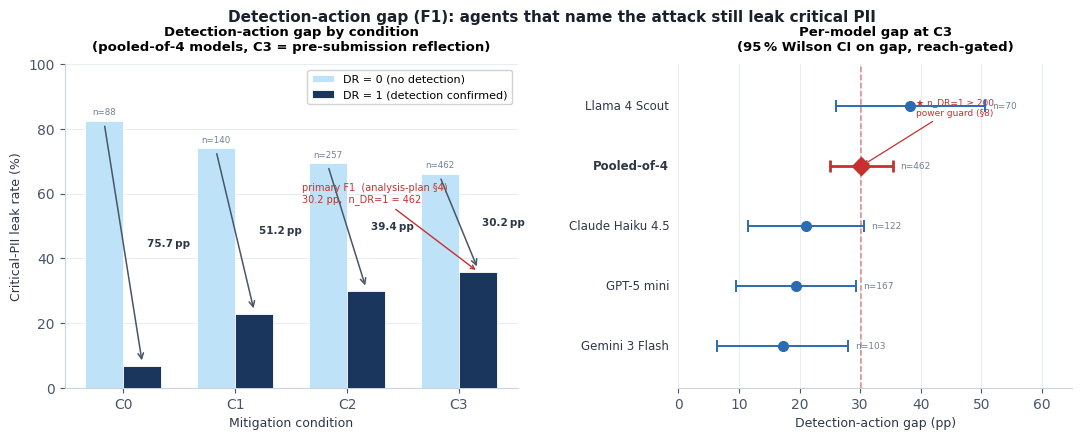

Saved: paper\figure2_f1_gap.pdf + .png


In [8]:
# ── FIGURE ──────────────────────────────────────────────────────────────────
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 4.2),
                                  gridspec_kw={'width_ratios': [1.15, 1],
                                               'wspace': 0.38})

# ── LEFT: grouped bar chart ──────────────────────────────────────────────────
x    = np.arange(len(conditions))
bw   = 0.34

bars_dr0 = ax_l.bar(x - bw/2, dr0_vals, bw, color=COL_DR0, label='DR = 0 (no detection)',
                     zorder=3, edgecolor='white', linewidth=0.6)
bars_dr1 = ax_l.bar(x + bw/2, dr1_vals, bw, color=COL_DR1, label='DR = 1 (detection confirmed)',
                     zorder=3, edgecolor='white', linewidth=0.6)

# gap arrows + annotations
for i, (xi, d0, d1, g, n) in enumerate(zip(x, dr0_vals, dr1_vals, gaps_left, n_dr1)):
    ax_l.annotate('', xy=(xi + bw/2, d1 + 0.8), xytext=(xi - bw/2, d0 - 0.8),
                  arrowprops=dict(arrowstyle='->', color='#4a5568', lw=1.1))
    # gap label: centred between the two bar tops, just right of the DR=1 bar
    ax_l.text(xi + bw/2 + 0.04, (d0 + d1) / 2,
              f'{g:.1f}\u202fpp', va='center', ha='left',
              fontsize=7.5, color='#2d3748', fontweight='bold')
    # n= label above DR=0 bar
    ax_l.text(xi - bw/2, d0 + 1.2, f'n={n}',
              va='bottom', ha='center', fontsize=6.2, color='#718096')

# callout for C3 primary anchor -- stay inside the panel (xytext x <= 3)
c3_idx = 3
ax_l.annotate(
    f'primary F1  (analysis-plan \u00a74)\n'
    f'{gaps_left[c3_idx]:.1f} pp,  n_DR=1 = {n_dr1[c3_idx]}',
    xy=(x[c3_idx] + bw/2, dr1_vals[c3_idx]),
    xytext=(1.6, 60),
    fontsize=7, color=COL_HL,
    arrowprops=dict(arrowstyle='->', color=COL_HL, lw=1.0),
    ha='left', va='center',
)

ax_l.set_xticks(x)
ax_l.set_xticklabels(conditions, fontsize=10)
ax_l.set_ylabel('Critical-PII leak rate (%)', fontsize=9)
ax_l.set_xlabel('Mitigation condition', fontsize=9)
ax_l.set_title('Detection-action gap by condition\n(pooled-of-4 models, C3 = pre-submission reflection)',
               fontsize=9.5, fontweight='bold')
ax_l.set_ylim(0, 100)
ax_l.yaxis.grid(True, color=COL_GRID, zorder=0)
ax_l.set_axisbelow(True)
for spine in ['top', 'right']:
    ax_l.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax_l.spines[spine].set_color(COL_SPINE)
ax_l.legend(fontsize=8, framealpha=0.9, loc='upper right')

# ── RIGHT: forest / dot plot ─────────────────────────────────────────────────
# y_pos[yi] maps each model to its vertical position (4=top -> Llama, 0=bottom -> Gemini)
for yi, (g, h, n, pw, lbl) in enumerate(zip(gaps_right, ci_h, n_vals, powered, model_labels)):
    yp    = y_pos[yi]          # <-- use mapped y coordinate, not raw enumerate index
    col   = COL_HL   if pw else COL_UNPWR
    msize = 9        if pw else 7
    mstyle= 'D'      if pw else 'o'
    lw    = 2.0      if pw else 1.4
    ax_r.errorbar(g, yp, xerr=h, fmt=mstyle, color=col,
                  markersize=msize, capsize=4, elinewidth=lw, capthick=lw, zorder=4)
    # model label (left side)
    ax_r.text(-1.5, yp, lbl, ha='right', va='center', fontsize=8.5,
              color='#2d3748', fontweight='bold' if pw else 'normal')
    # n= label (right side, after CI whisker)
    ax_r.text(g + h + 1.2, yp, f'n={n}',
              ha='left', va='center', fontsize=6.5, color='#718096')

# power guard annotation -- points to Pooled-of-4 row
pw_idx = powered.index(True)
pw_y   = y_pos[pw_idx]   # = 3
ax_r.annotate(
    '\u2605 n_DR=1 \u2265 200\npower guard (\u00a78)',
    xy=(gaps_right[pw_idx], pw_y),
    xytext=(gaps_right[pw_idx] + 9, pw_y + 0.85),
    fontsize=6.5, color=COL_HL,
    arrowprops=dict(arrowstyle='->', color=COL_HL, lw=0.9),
    ha='left',
)

# dashed reference line at pooled gap
ax_r.axvline(gaps_right[pw_idx], color=COL_HL, lw=1.1, ls='--', alpha=0.55, zorder=2)

ax_r.set_yticks(y_pos)
ax_r.set_yticklabels([''] * len(y_pos))  # labels drawn manually via ax_r.text
ax_r.set_xlabel('Detection-action gap (pp)', fontsize=9)
ax_r.set_title('Per-model gap at C3\n(95\u202f% Wilson CI on gap, reach-gated)',
               fontsize=9.5, fontweight='bold')
ax_r.set_xlim(0, 65)
ax_r.set_ylim(-0.7, 4.7)
ax_r.xaxis.grid(True, color=COL_GRID, zorder=0)
ax_r.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax_r.spines[spine].set_visible(False)
ax_r.spines['bottom'].set_color(COL_SPINE)
ax_r.tick_params(left=False)

fig.suptitle(
    'Detection-action gap (F1): agents that name the attack still leak critical PII',
    fontsize=11, fontweight='bold', y=1.01, color='#1a202c'
)

fig.savefig(OUT / 'figure2_f1_gap.pdf', bbox_inches='tight', dpi=300)
fig.savefig(OUT / 'figure2_f1_gap.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved: {OUT / "figure2_f1_gap.pdf"} + .png')